In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple, List, Optional

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
class ToyMaskingOperator:
    """Random binary masking operator (Ambient Diffusion)"""
    def __init__(self, p: float = 0.6, delta: float = 0.1):
        self.p = p
        self.delta = delta

    def corrupt_and_hat_corrupt(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        mask_A = (torch.rand_like(x) > self.p).float()
        mask_B = (torch.rand_like(x) > self.delta).float()
        hat_mask = mask_A * mask_B
        return mask_A, hat_mask


class PreconditionedScoreNet(nn.Module):
    """Score network with EDM preconditioning"""
    def __init__(self, in_dim: int = 2, hidden_dim: int = 512, num_layers: int = 3, sigma_data: float = 0.5):
        super().__init__()
        self.sigma_data = sigma_data
        self.in_dim = in_dim

        layers = []
        for i in range(num_layers):
            in_features = (in_dim * 2 + 1) if i == 0 else hidden_dim
            out_features = hidden_dim if i < num_layers - 1 else in_dim
            layers.append(nn.Linear(in_features, out_features))
            if i < num_layers - 1:
                layers.append(nn.GELU())

        self.net = nn.Sequential(*layers)

    def forward(self, x_tilde: torch.Tensor, sigma: torch.Tensor, hat_mask: torch.Tensor) -> torch.Tensor:
        c_skip = self.sigma_data**2 / (sigma**2 + self.sigma_data**2)
        c_out = sigma * self.sigma_data / (sigma**2 + self.sigma_data**2).sqrt()
        c_in = 1 / (sigma**2 + self.sigma_data**2).sqrt()
        c_noise = (sigma.log() / 4.0).expand(-1, 1)

        x_in = x_tilde * c_in
        cat_input = torch.cat([x_in, hat_mask, c_noise], dim=1)
        F_x = self.net(cat_input)
        D_x = c_skip * x_tilde + c_out * F_x
        return D_x


def get_scheduler(num_steps: int = 50, sigma_begin: float = 10.0, sigma_end: float = 0.01) -> torch.Tensor:
    """Create noise schedule"""
    return torch.exp(torch.linspace(np.log(sigma_begin), np.log(sigma_end), num_steps))

In [3]:
def generate_two_moons(n_samples: int = 20000, noise: float = 0.05) -> torch.Tensor:
    """Generates a normalized Two Moons dataset"""
    X_np, _ = make_moons(n_samples=n_samples, noise=noise)
    X_np = (X_np - X_np.mean(axis=0)) / X_np.std(axis=0)
    return torch.tensor(X_np, dtype=torch.float32)


def generate_gmm(n_samples: int = 100000, num_clusters: int = 3, seed: Optional[int] = None) -> torch.Tensor:
    """Generates a GMM dataset with configurable clusters"""
    if seed is not None:
        np.random.seed(seed)

    means = [np.array([4.0, 4.0]), np.array([-4.0, -4.0]), np.array([4.0, -3.0])][:num_clusters]
    covs = [
        np.array([[2.0, 1.8], [1.8, 2.0]]),
        np.array([[2.5, -2.0], [-2.0, 2.5]]),
        np.array([[0.3, 0.0], [0.0, 3.0]]),
    ][:num_clusters]

    choices = np.random.choice(list(range(num_clusters)), size=n_samples)
    X = np.zeros((n_samples, 2))
    for i in range(num_clusters):
        mask_c = choices == i
        X[mask_c] = np.random.multivariate_normal(means[i], covs[i], np.sum(mask_c))

    X = (X - X.mean(axis=0)) / X.std(axis=0)
    return torch.tensor(X, dtype=torch.float32)

In [4]:
from tqdm import tqdm
from sklearn.neighbors import KernelDensity

def train_score_net(
    model: nn.Module,
    data: torch.Tensor,
    operator: ToyMaskingOperator,
    epochs: int = 1000,
    batch_size: int = 1024,
    sigma_data: float = 0.5,
    p_mean: float = -1.2,
    p_std: float = 1.2,
    lr: float = 5e-4,
) -> Tuple[nn.Module, List[float]]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in tqdm(range(epochs), desc="train_score_net"):
        idx = torch.randint(0, len(data), (batch_size,))
        y = data[idx].to(device)

        rnd_normal = torch.randn(batch_size, 1, device=device)
        sigma = (rnd_normal * p_std + p_mean).exp()
        weight = ((sigma**2 + sigma_data**2) / (sigma * sigma_data) ** 2)

        n = torch.randn_like(y) * sigma
        noisy_y = y + n

        mask_A, hat_mask = operator.corrupt_and_hat_corrupt(y)
        masked_noisy = hat_mask * noisy_y

        D_yn = model(masked_noisy, sigma, hat_mask)
        loss = torch.mean(weight * ((mask_A * (D_yn - y)) ** 2))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    return model, history

def train_standard_diffusion(
    model: nn.Module,
    data: torch.Tensor,
    epochs: int = 1000,
    batch_size: int = 1024,
    sigma_data: float = 0.5,
    p_mean: float = -1.2,
    p_std: float = 1.2,
    lr: float = 5e-4,
) -> Tuple[nn.Module, List[float]]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in tqdm(range(epochs), desc="train_standard_diffusion"):
        idx = torch.randint(0, len(data), (batch_size,))
        y = data[idx].to(device)

        rnd_normal = torch.randn(batch_size, 1, device=device)
        sigma = (rnd_normal * p_std + p_mean).exp()
        weight = ((sigma**2 + sigma_data**2) / (sigma * sigma_data) ** 2)

        n = torch.randn_like(y) * sigma
        noisy_y = y + n
        dummy_mask = torch.ones_like(y, device=device)

        D_yn = model(noisy_y, sigma, dummy_mask)
        loss = torch.mean(weight * ((D_yn - y) ** 2))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    return model, history

def train_naive_diffusion(
    model: nn.Module,
    data: torch.Tensor,
    operator: ToyMaskingOperator,
    epochs: int = 1000,
    batch_size: int = 1024,
    sigma_data: float = 0.5,
    p_mean: float = -1.2,
    p_std: float = 1.2,
    lr: float = 5e-4,
) -> Tuple[nn.Module, List[float]]:
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in tqdm(range(epochs), desc="train_naive_diffusion"):
        idx = torch.randint(0, len(data), (batch_size,))
        y = data[idx].to(device)

        rnd_normal = torch.randn(batch_size, 1, device=device)
        sigma = (rnd_normal * p_std + p_mean).exp()
        weight = ((sigma**2 + sigma_data**2) / (sigma * sigma_data) ** 2)

        mask_A, _ = operator.corrupt_and_hat_corrupt(y)
        y_corrupted = y * mask_A

        n = torch.randn_like(y_corrupted) * sigma
        noisy_y_corrupted = y_corrupted + n

        D_yn = model(noisy_y_corrupted, sigma, mask_A)
        loss = torch.mean(weight * ((mask_A * (D_yn - y_corrupted)) ** 2))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        history.append(loss.item())

    return model, history

def compute_metrics(real_data: torch.Tensor, generated_data: torch.Tensor, device=device) -> dict:
    """
    Compute KDE Log-Likelihood, MMD, and Sliced Wasserstein Distance.
    real_data and generated_data should be tensors of shape (N, 2).
    """
    min_samples = min(len(real_data), len(generated_data))

    real_np = real_data[:min_samples].cpu().numpy()
    gen_np = generated_data[:min_samples].cpu().numpy()

    real_t = real_data[:min_samples].to(device)
    gen_t = generated_data[:min_samples].to(device)

    metrics = {}

    kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(real_np)
    log_pdf = kde.score_samples(gen_np)
    metrics['KDE_LogLikelihood'] = np.mean(log_pdf)

    def rbf_kernel(x, y, sigma=1.0):
        dist = torch.cdist(x, y)**2
        return torch.exp(-dist / (2 * sigma**2))

    k_xx = rbf_kernel(real_t, real_t).mean()
    k_yy = rbf_kernel(gen_t, gen_t).mean()
    k_xy = rbf_kernel(real_t, gen_t).mean()
    metrics['MMD'] = (k_xx + k_yy - 2 * k_xy).item()

    num_projections = 50
    theta = torch.rand(num_projections, device=device) * 2 * np.pi
    projections = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)

    real_proj = torch.matmul(real_t, projections.T)
    gen_proj = torch.matmul(gen_t, projections.T)

    real_proj, _ = torch.sort(real_proj, dim=0)
    gen_proj, _ = torch.sort(gen_proj, dim=0)

    swd = torch.mean((real_proj - gen_proj)**2)
    metrics['SWD'] = swd.item()

    return metrics

def sample_score_net(
    model: nn.Module,
    num_samples: int,
    sigmas: torch.Tensor,
) -> np.ndarray:
    """Generate samples using an ODE solver."""
    model.eval()
    x_t = torch.randn(num_samples, 2, device=device) * 10.0
    mask = torch.ones_like(x_t)

    with torch.no_grad():
        for i in range(len(sigmas) - 1):
            sigma_t = sigmas[i].to(device)
            sigma_t_next = sigmas[i + 1].to(device)
            sigma_tensor = torch.full((num_samples, 1), sigma_t.item(), device=device)
            pred_x0 = model(mask * x_t, sigma_tensor, mask)
            d = (x_t - pred_x0) / sigma_t
            x_euler = x_t + d * (sigma_t_next - sigma_t)

            sigma_tensor_next = torch.full((num_samples, 1), sigma_t_next.item(), device=device)
            pred_x0_next = model(mask * x_euler, sigma_tensor_next, mask)
            d_next = (x_euler - pred_x0_next) / sigma_t_next
            x_t = x_t + 0.5 * (d + d_next) * (sigma_t_next - sigma_t)

        final_sigma = torch.full((num_samples, 1), sigmas[-1].item(), device=device)
        final_pred = model(mask * x_t, final_sigma, mask)

    return final_pred.cpu().numpy()

In [5]:
def plot_comparison(real: np.ndarray, generated: np.ndarray, title: str = "Comparison", figsize: Tuple[int, int] = (6, 6)):
    """Compare real vs generated samples."""
    plt.figure(figsize=figsize)
    plt.scatter(real[:, 0], real[:, 1], s=5, alpha=0.3, c='blue', label='Real')
    plt.scatter(generated[:, 0], generated[:, 1], s=5, alpha=0.5, c='red', label='Generated')
    plt.legend()
    plt.title(title)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def plot_all_results(real_data: np.ndarray, standard_gen: np.ndarray, ambient_gens: dict, title: str):
    """Create a comparison grid: Real | Standard | Ambient p1 | Ambient p2 ..."""
    n_plots = 2 + len(ambient_gens)
    fig, axs = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))

    axs[0].scatter(real_data[:, 0], real_data[:, 1], s=5, alpha=0.5, c='blue')
    axs[0].set_title("1. Ground Truth")
    axs[0].axis('equal')

    axs[1].scatter(standard_gen[:, 0], standard_gen[:, 1], s=5, alpha=0.5, c='green')
    axs[1].set_title("2. Standard Diffusion")
    axs[1].axis('equal')

    for i, (p, gen_data) in enumerate(ambient_gens.items()):
        axs[2 + i].scatter(gen_data[:, 0], gen_data[:, 1], s=5, alpha=0.5, c='red')
        axs[2 + i].set_title(f"{3+i}. Ambient Diffusion (p={p})")
        axs[2 + i].axis('equal')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


def plot_loss_curve(history: List[float], title: str = "Loss Curve", smooth_window: int = 50, yscale: str = 'log'):
    """Plot training loss curve."""
    plt.figure(figsize=(8, 4))
    smoothed = np.convolve(history, np.ones(smooth_window) / smooth_window, mode='valid')
    plt.plot(smoothed, alpha=0.8, linewidth=2)
    plt.yscale(yscale)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def visualize_before_training(
    data: torch.Tensor,
    operator: ToyMaskingOperator,
    num_visu: int = 2000,
    title: str = "Data Before Training",
    xlim: Tuple[float, float] = (-2.5, 2.5),
    ylim: Tuple[float, float] = (-2.5, 2.5),
):
    """Visualize real vs corrupted data before training."""
    X_visu = data[:num_visu]
    mask_A, _ = operator.corrupt_and_hat_corrupt(X_visu)
    X_corrupted = X_visu * mask_A

    real_np = X_visu.numpy()
    corrupted_np = X_corrupted.numpy()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    ax1.scatter(real_np[:, 0], real_np[:, 1], s=10, alpha=0.5, c='blue', label='Real Points')
    ax1.set_title("Ground Truth (Hidden)")
    ax1.set_xlim(xlim)
    ax1.set_ylim(ylim)
    ax1.axis('equal')
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    ax2.scatter(corrupted_np[:, 0], corrupted_np[:, 1], s=10, alpha=0.3, c='orange', label='Corrupted Points')
    ax2.set_title("Corrupted Data")
    ax2.set_xlim(xlim)
    ax2.set_ylim(ylim)
    ax2.axis('equal')
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.legend()

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_score_field_2d(model: nn.Module, sigma_val: float = 0.5,
                        title: str = "Learned Score Field", figsize=(6, 6)):
    """Display the learned 2D score field at noise level sigma_val."""
    model.eval()

    # Create a 2D grid
    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)

    grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    # Unconditional score (mask all ones, no inpainting at inference)
    dummy_mask = torch.ones_like(grid_tensor, device=device)
    sigma_tensor = torch.full((len(grid_tensor), 1), sigma_val, device=device)

    with torch.no_grad():
        # D_x is the conditional expectation E[x0 | xt]
        pred_x0 = model(grid_tensor, sigma_tensor, dummy_mask)
        # Tweedie: score direction ~ (E[x0|xt] - xt); scale by sigma^2 ignored for plot
        score_dir = (pred_x0 - grid_tensor).cpu().numpy()

    U = score_dir[:, 0].reshape(20, 20)
    V = score_dir[:, 1].reshape(20, 20)

    plt.figure(figsize=figsize)
    plt.quiver(X, Y, U, V, color='purple', alpha=0.7)
    plt.title(f"{title} (sigma={sigma_val})")
    plt.xlim(-3, 3)
    plt.ylim(-3, 3)
    plt.grid(True, alpha=0.3)
    plt.show()

In [7]:
def generate_spread_gmm(n_samples: int = 20000, distance: float = 4.0):
    """Generates 3 Gaussian clusters far from the origin and axes."""
    centers = torch.tensor([
        [distance, distance],
        [-distance, distance],
        [0.0, -distance * 1.5]
    ])

    cluster_assignments = torch.randint(0, 3, (n_samples,))

    noise = torch.randn(n_samples, 2) * 0.5

    data = centers[cluster_assignments] + noise
    return data

>>> STARTING EXPERIMENT 1: ABLATION
0. Visualizing data before training...


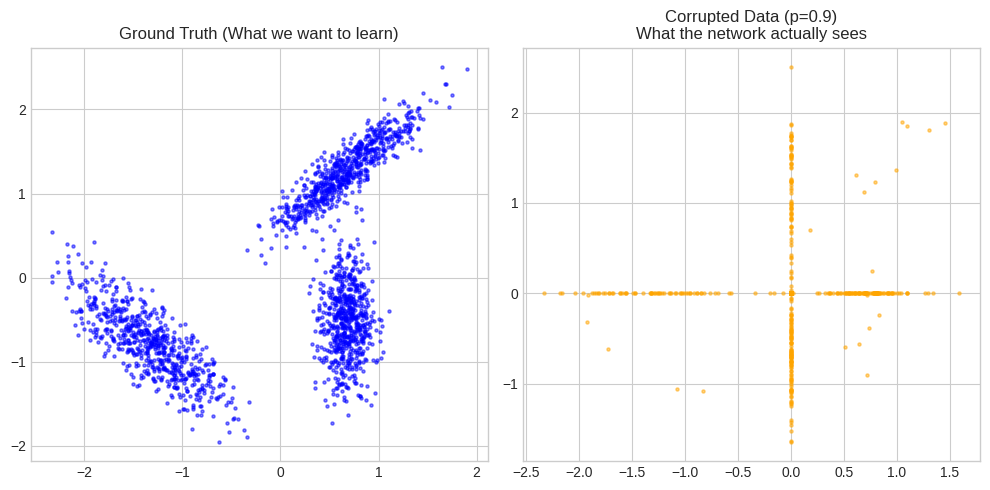

1. Standard Training...


train_standard_diffusion: 100%|██████████| 20000/20000 [00:45<00:00, 439.30it/s]


2. Naive Training (Will collapse)...


train_naive_diffusion: 100%|██████████| 20000/20000 [00:48<00:00, 410.89it/s]


3. Ambient Training...


train_score_net: 100%|██████████| 20000/20000 [00:48<00:00, 416.17it/s]



QUANTITATIVE METRICS: ABLATION (SPREAD GMM)
Model                | KDE LL (↑)   | MMD (↓)    | SWD (↓)   
-----------------------------------------------------------------
1. Standard          |        -1.35 |     0.0006 |     0.0029
2. Naive (Collapsed) |        -2.21 |     0.0053 |     0.0200
3. Ambient           |        -1.73 |     0.0017 |     0.0083



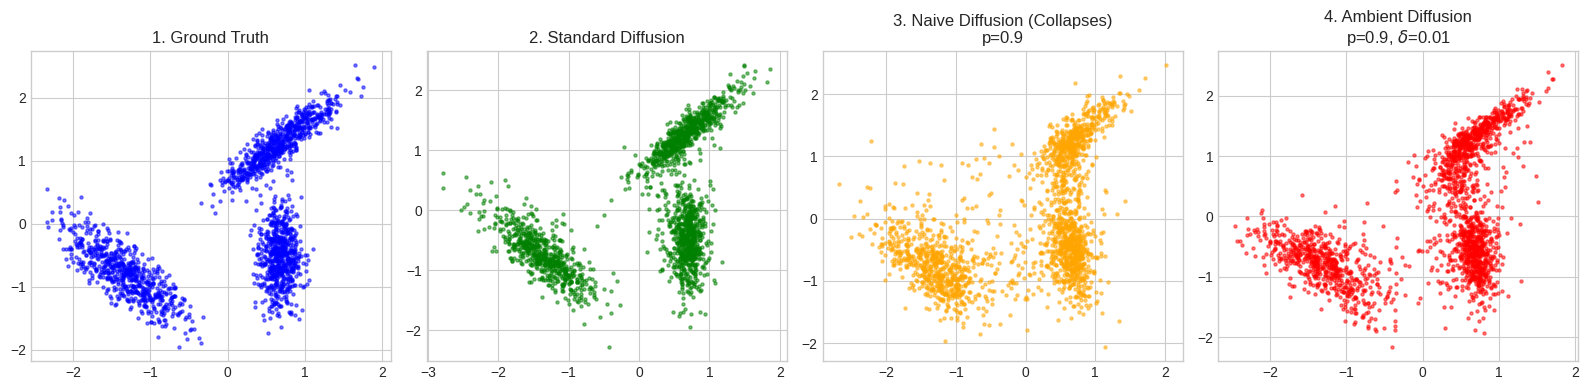

Generating vector fields...


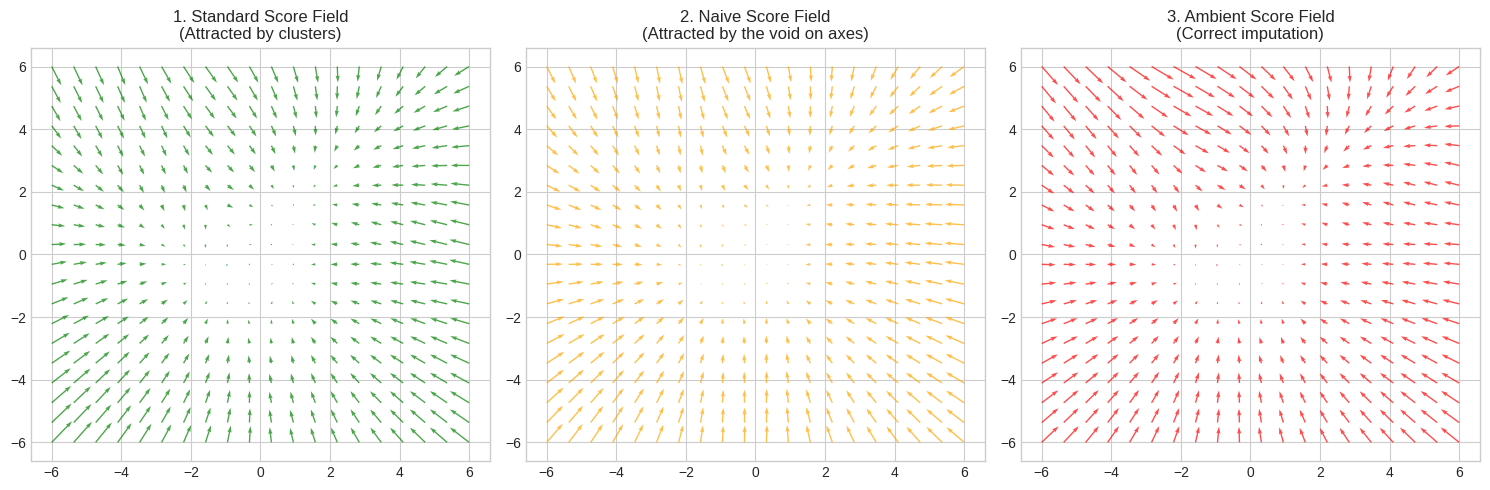

In [8]:
# ==============================================================================
# EXPERIMENT 1: ABLATION ON SPREAD GMM (Naive vs Ambient)
# Objective: Show that equation 3.1 collapses onto the axes without further corruption
# ==============================================================================
print(">>> STARTING EXPERIMENT 1: ABLATION")
data_exp1 = generate_gmm(n_samples=10000)
p_val, delta_val, epochs_exp1 = 0.9, 0.01, 20000
operator_exp1 = ToyMaskingOperator(p=p_val, delta=delta_val)

# --- 0. VISUALIZING CORRUPTED DATA (WHAT THE NETWORK SEES) ---
print("0. Visualizing data before training...")
mask_A, _ = operator_exp1.corrupt_and_hat_corrupt(data_exp1)
data_corrupted = data_exp1 * mask_A

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(data_exp1[:2000, 0].numpy(), data_exp1[:2000, 1].numpy(), s=5, alpha=0.5, c='blue')
axs[0].set_title("Ground Truth (What we want to learn)")
axs[1].scatter(data_corrupted[:2000, 0].numpy(), data_corrupted[:2000, 1].numpy(), s=5, alpha=0.5, c='orange')
axs[1].set_title(f"Corrupted Data (p={p_val})\nWhat the network actually sees")

plt.tight_layout()
plt.savefig("exp1_corrupted_data.pdf")
plt.show()

# --- 1. TRAINING ---
print("1. Standard Training...")
mod_std_1, _ = train_standard_diffusion(PreconditionedScoreNet(hidden_dim=32), data_exp1, epochs=epochs_exp1)
print("2. Naive Training (Will collapse)...")
mod_nai_1, _ = train_naive_diffusion(PreconditionedScoreNet(hidden_dim=32), data_exp1, operator_exp1, epochs=epochs_exp1)
print("3. Ambient Training...")
mod_amb_1, _ = train_score_net(PreconditionedScoreNet(hidden_dim=32), data_exp1, operator_exp1, epochs=epochs_exp1)

# --- 2. GENERATION ---
sigmas = get_scheduler(num_steps=100)
gen_std_1 = sample_score_net(mod_std_1, 2000, sigmas)
gen_nai_1 = sample_score_net(mod_nai_1, 2000, sigmas)
gen_amb_1 = sample_score_net(mod_amb_1, 2000, sigmas)

# --- 3. METRICS CALCULATION AND DISPLAY ---
print("\n" + "="*65)
print("QUANTITATIVE METRICS: ABLATION (SPREAD GMM)")
print("="*65)

real_data_sample = data_exp1[:2000]
metrics_std = compute_metrics(real_data_sample, torch.tensor(gen_std_1, dtype=torch.float32))
metrics_nai = compute_metrics(real_data_sample, torch.tensor(gen_nai_1, dtype=torch.float32))
metrics_amb = compute_metrics(real_data_sample, torch.tensor(gen_amb_1, dtype=torch.float32))

print(f"{'Model':<20} | {'KDE LL (↑)':<12} | {'MMD (↓)':<10} | {'SWD (↓)':<10}")
print("-" * 65)
print(f"{'1. Standard':<20} | {metrics_std['KDE_LogLikelihood']:12.2f} | {metrics_std['MMD']:10.4f} | {metrics_std['SWD']:10.4f}")
print(f"{'2. Naive (Collapsed)':<20} | {metrics_nai['KDE_LogLikelihood']:12.2f} | {metrics_nai['MMD']:10.4f} | {metrics_nai['SWD']:10.4f}")
print(f"{'3. Ambient':<20} | {metrics_amb['KDE_LogLikelihood']:12.2f} | {metrics_amb['MMD']:10.4f} | {metrics_amb['SWD']:10.4f}")
print("="*65 + "\n")

# --- 4. FIGURE 1: SCATTER PLOTS ---
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].scatter(data_exp1[:2000, 0].numpy(), data_exp1[:2000, 1].numpy(), s=5, alpha=0.5, c='blue')
axs[0].set_title("1. Ground Truth")
axs[1].scatter(gen_std_1[:, 0], gen_std_1[:, 1], s=5, alpha=0.5, c='green')
axs[1].set_title("2. Standard Diffusion")
axs[2].scatter(gen_nai_1[:, 0], gen_nai_1[:, 1], s=5, alpha=0.5, c='orange')
axs[2].set_title(f"3. Naive Diffusion (Collapses)\np={p_val}")
axs[3].scatter(gen_amb_1[:, 0], gen_amb_1[:, 1], s=5, alpha=0.5, c='red')
axs[3].set_title(f"4. Ambient Diffusion\np={p_val}, $\\delta$={delta_val}")

plt.tight_layout()
plt.savefig("exp1_scatter.pdf") # Save for LaTeX!
plt.show()

# --- 5. FIGURE 2: SCORE FIELDS (SIDE-BY-SIDE) ---
print("Generating vector fields...")
sigma_val = 0.5

# 1. 2D Grid adapted for the spread GMM (-6 to 6)
x_range = np.linspace(-6, 6, 20)
y_range = np.linspace(-6, 6, 20)
X, Y = np.meshgrid(x_range, y_range)

grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)
dummy_mask = torch.ones_like(grid_tensor, device=device)
sigma_tensor = torch.full((len(grid_tensor), 1), sigma_val, device=device)

# 2. Local function to extract (U, V) from a model
def get_uv(model):
    model.eval()
    with torch.no_grad():
        pred_x0 = model(grid_tensor, sigma_tensor, dummy_mask)
        score_dir = (pred_x0 - grid_tensor).cpu().numpy()
    return score_dir[:, 0].reshape(20, 20), score_dir[:, 1].reshape(20, 20)

# 3. Retrieve vectors
U_std, V_std = get_uv(mod_std_1)
U_nai, V_nai = get_uv(mod_nai_1)
U_amb, V_amb = get_uv(mod_amb_1)

# 4. Side-by-side display
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].quiver(X, Y, U_std, V_std, color='green', alpha=0.7)
axs[0].set_title(f"1. Standard Score Field\n(Attracted by clusters)")

axs[1].quiver(X, Y, U_nai, V_nai, color='orange', alpha=0.7)
axs[1].set_title(f"2. Naive Score Field\n(Attracted by the void on axes)")

axs[2].quiver(X, Y, U_amb, V_amb, color='red', alpha=0.7)
axs[2].set_title(f"3. Ambient Score Field\n(Correct imputation)")

plt.tight_layout()
plt.savefig("exp1_quiver_comparison.pdf") # A single clean file for your LaTeX!
plt.show()

>>> STARTING EXPERIMENT 1: ABLATION
0. Visualizing data before training...


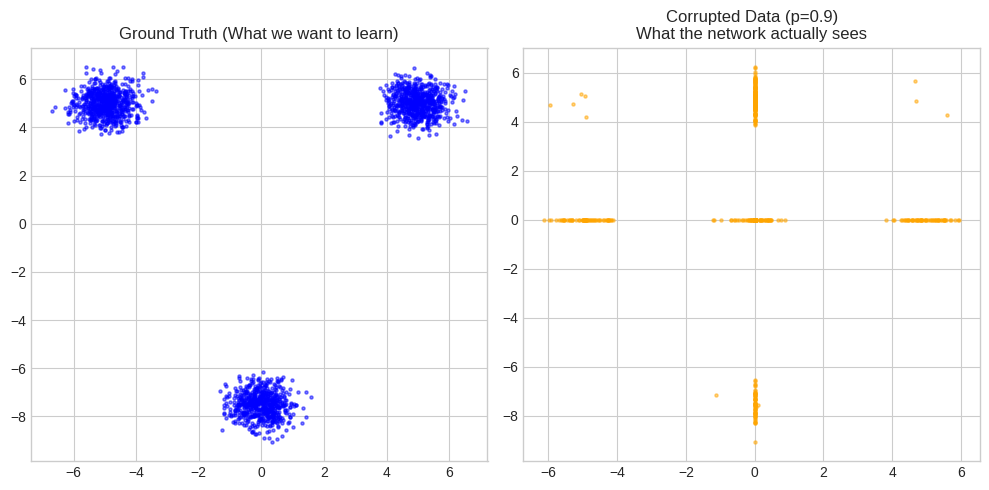

1. Standard Training...


train_standard_diffusion: 100%|██████████| 20000/20000 [00:45<00:00, 442.07it/s]


2. Naive Training (Will collapse)...


train_naive_diffusion: 100%|██████████| 20000/20000 [00:47<00:00, 419.31it/s]


3. Ambient Training...


train_score_net: 100%|██████████| 20000/20000 [00:47<00:00, 417.48it/s]



QUANTITATIVE METRICS: ABLATION (SPREAD GMM)
Model                | KDE LL (↑)   | MMD (↓)    | SWD (↓)   
-----------------------------------------------------------------
1. Standard          |        -3.56 |     0.0025 |     0.0804
2. Naive (Collapsed) |       -40.46 |     0.0230 |     1.2748
3. Ambient           |        -5.86 |     0.0180 |     4.4515



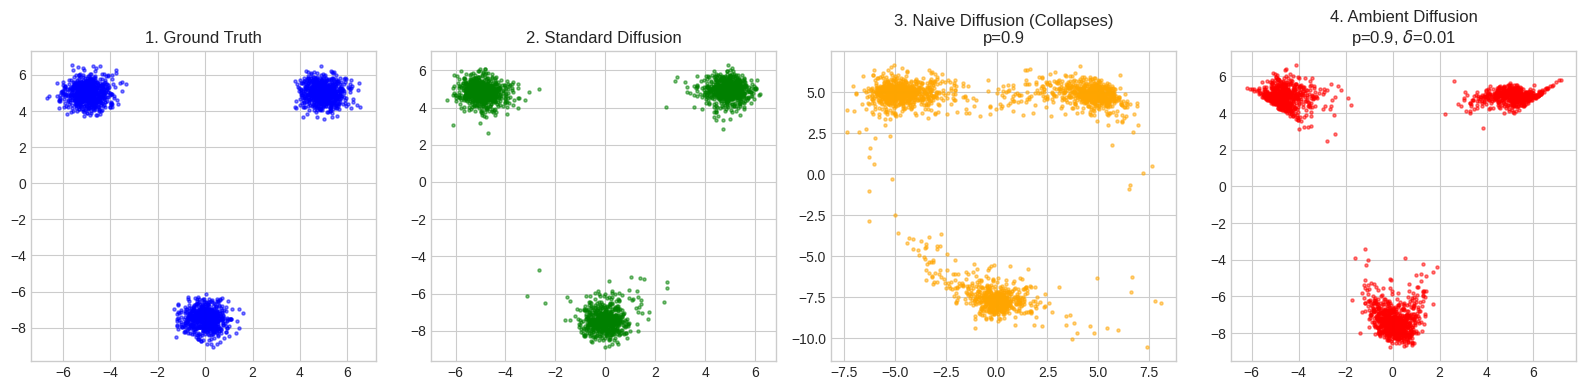

Generating vector fields...


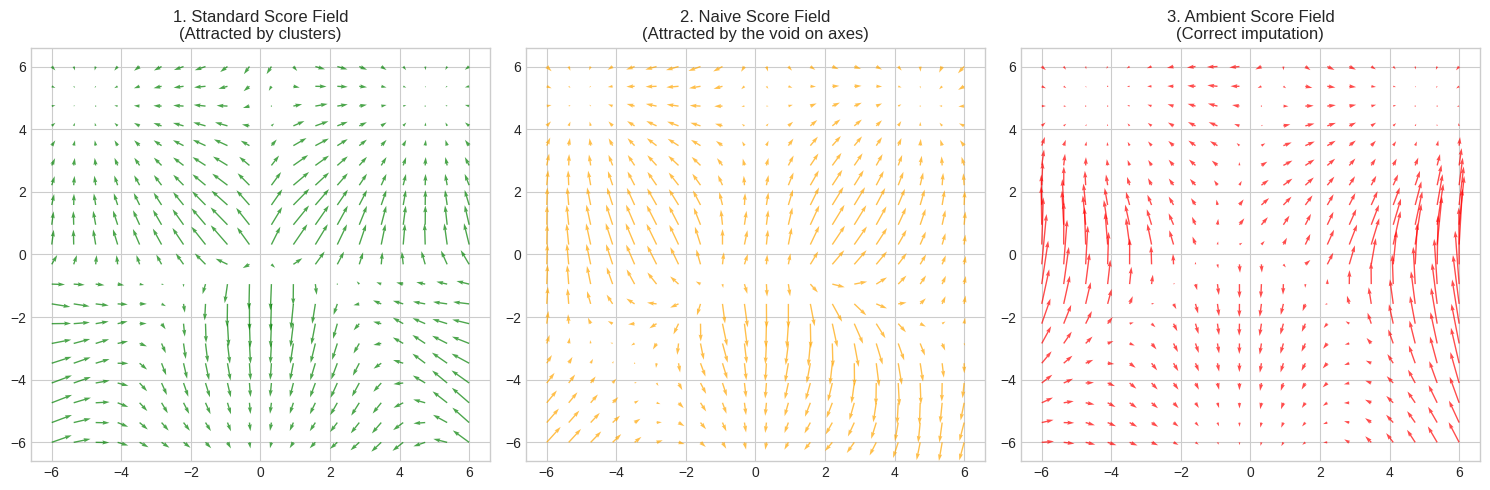

In [9]:
# ==============================================================================
# EXPERIMENT 1: ABLATION ON SPREAD GMM (Naive vs Ambient)
# Objective: Show that equation 3.1 collapses onto the axes without further corruption
# ==============================================================================
print(">>> STARTING EXPERIMENT 1: ABLATION")
data_exp1 = generate_spread_gmm(n_samples=10000, distance=5.0)
p_val, delta_val, epochs_exp1 = 0.9, 0.01, 20000
operator_exp1 = ToyMaskingOperator(p=p_val, delta=delta_val)

# --- 0. VISUALIZING CORRUPTED DATA (WHAT THE NETWORK SEES) ---
print("0. Visualizing data before training...")
mask_A, _ = operator_exp1.corrupt_and_hat_corrupt(data_exp1)
data_corrupted = data_exp1 * mask_A

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(data_exp1[:2000, 0].numpy(), data_exp1[:2000, 1].numpy(), s=5, alpha=0.5, c='blue')
axs[0].set_title("Ground Truth (What we want to learn)")
axs[1].scatter(data_corrupted[:2000, 0].numpy(), data_corrupted[:2000, 1].numpy(), s=5, alpha=0.5, c='orange')
axs[1].set_title(f"Corrupted Data (p={p_val})\nWhat the network actually sees")

plt.tight_layout()
plt.savefig("exp1_corrupted_data.pdf")
plt.show()

# --- 1. TRAINING ---
print("1. Standard Training...")
mod_std_1, _ = train_standard_diffusion(PreconditionedScoreNet(hidden_dim=32), data_exp1, epochs=epochs_exp1)
print("2. Naive Training (Will collapse)...")
mod_nai_1, _ = train_naive_diffusion(PreconditionedScoreNet(hidden_dim=32), data_exp1, operator_exp1, epochs=epochs_exp1)
print("3. Ambient Training...")
mod_amb_1, _ = train_score_net(PreconditionedScoreNet(hidden_dim=32), data_exp1, operator_exp1, epochs=epochs_exp1)

# --- 2. GENERATION ---
sigmas = get_scheduler(num_steps=100)
gen_std_1 = sample_score_net(mod_std_1, 2000, sigmas)
gen_nai_1 = sample_score_net(mod_nai_1, 2000, sigmas)
gen_amb_1 = sample_score_net(mod_amb_1, 2000, sigmas)

# --- 3. METRICS CALCULATION AND DISPLAY ---
print("\n" + "="*65)
print("QUANTITATIVE METRICS: ABLATION (SPREAD GMM)")
print("="*65)

real_data_sample = data_exp1[:2000]
metrics_std = compute_metrics(real_data_sample, torch.tensor(gen_std_1, dtype=torch.float32))
metrics_nai = compute_metrics(real_data_sample, torch.tensor(gen_nai_1, dtype=torch.float32))
metrics_amb = compute_metrics(real_data_sample, torch.tensor(gen_amb_1, dtype=torch.float32))

print(f"{'Model':<20} | {'KDE LL (↑)':<12} | {'MMD (↓)':<10} | {'SWD (↓)':<10}")
print("-" * 65)
print(f"{'1. Standard':<20} | {metrics_std['KDE_LogLikelihood']:12.2f} | {metrics_std['MMD']:10.4f} | {metrics_std['SWD']:10.4f}")
print(f"{'2. Naive (Collapsed)':<20} | {metrics_nai['KDE_LogLikelihood']:12.2f} | {metrics_nai['MMD']:10.4f} | {metrics_nai['SWD']:10.4f}")
print(f"{'3. Ambient':<20} | {metrics_amb['KDE_LogLikelihood']:12.2f} | {metrics_amb['MMD']:10.4f} | {metrics_amb['SWD']:10.4f}")
print("="*65 + "\n")

# --- 4. FIGURE 1: SCATTER PLOTS ---
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].scatter(data_exp1[:2000, 0].numpy(), data_exp1[:2000, 1].numpy(), s=5, alpha=0.5, c='blue')
axs[0].set_title("1. Ground Truth")
axs[1].scatter(gen_std_1[:, 0], gen_std_1[:, 1], s=5, alpha=0.5, c='green')
axs[1].set_title("2. Standard Diffusion")
axs[2].scatter(gen_nai_1[:, 0], gen_nai_1[:, 1], s=5, alpha=0.5, c='orange')
axs[2].set_title(f"3. Naive Diffusion (Collapses)\np={p_val}")
axs[3].scatter(gen_amb_1[:, 0], gen_amb_1[:, 1], s=5, alpha=0.5, c='red')
axs[3].set_title(f"4. Ambient Diffusion\np={p_val}, $\\delta$={delta_val}")

plt.tight_layout()
plt.savefig("exp1_scatter.pdf") # Save for LaTeX!
plt.show()

# --- 5. FIGURE 2: SCORE FIELDS (SIDE-BY-SIDE) ---
print("Generating vector fields...")
sigma_val = 0.5

# 1. 2D Grid adapted for the spread GMM (-6 to 6)
x_range = np.linspace(-6, 6, 20)
y_range = np.linspace(-6, 6, 20)
X, Y = np.meshgrid(x_range, y_range)

grid_points = np.stack([X.flatten(), Y.flatten()], axis=1)
grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)
dummy_mask = torch.ones_like(grid_tensor, device=device)
sigma_tensor = torch.full((len(grid_tensor), 1), sigma_val, device=device)

# 2. Local function to extract (U, V) from a model
def get_uv(model):
    model.eval()
    with torch.no_grad():
        pred_x0 = model(grid_tensor, sigma_tensor, dummy_mask)
        score_dir = (pred_x0 - grid_tensor).cpu().numpy()
    return score_dir[:, 0].reshape(20, 20), score_dir[:, 1].reshape(20, 20)

# 3. Retrieve vectors
U_std, V_std = get_uv(mod_std_1)
U_nai, V_nai = get_uv(mod_nai_1)
U_amb, V_amb = get_uv(mod_amb_1)

# 4. Side-by-side display
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].quiver(X, Y, U_std, V_std, color='green', alpha=0.7)
axs[0].set_title(f"1. Standard Score Field\n(Attracted by clusters)")

axs[1].quiver(X, Y, U_nai, V_nai, color='orange', alpha=0.7)
axs[1].set_title(f"2. Naive Score Field\n(Attracted by the void on axes)")

axs[2].quiver(X, Y, U_amb, V_amb, color='red', alpha=0.7)
axs[2].set_title(f"3. Ambient Score Field\n(Correct imputation)")

plt.tight_layout()
plt.savefig("exp1_quiver_comparison.pdf") # A single clean file for your LaTeX!
plt.show()

>>> STARTING EXPERIMENT 2: TWO MOONS
0. Visualizing data before training...


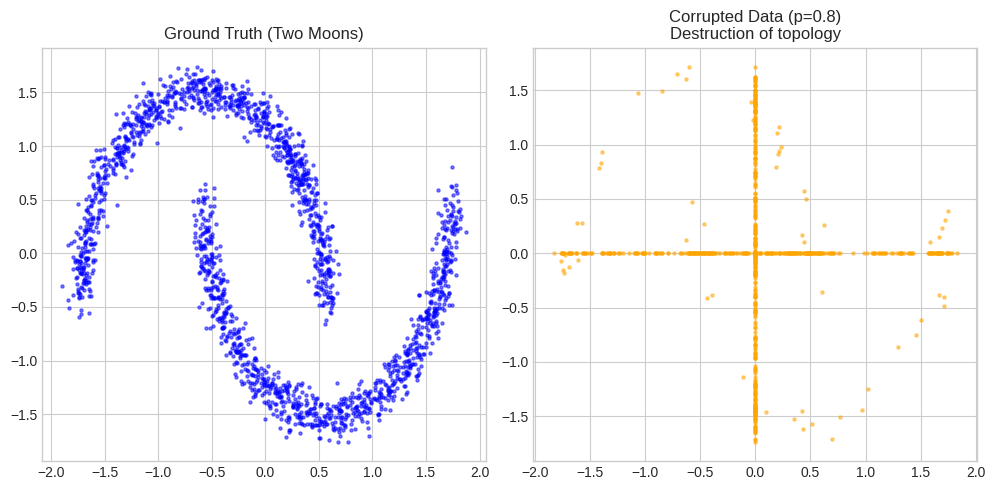

1. Standard (Clean Data)...


train_standard_diffusion: 100%|██████████| 50000/50000 [01:56<00:00, 429.18it/s]


2. Naive (Will collapse)...


train_naive_diffusion: 100%|██████████| 50000/50000 [02:04<00:00, 402.80it/s]


3. Ambient (Corrupted Data)...


train_score_net: 100%|██████████| 50000/50000 [02:03<00:00, 403.41it/s]



QUANTITATIVE METRICS: TOPOLOGY (TWO MOONS)
Model                | KDE LL (↑)   | MMD (↓)    | SWD (↓)   
-----------------------------------------------------------------
1. Standard          |        -1.40 |     0.0004 |     0.0015
2. Naive (Collapsed) |        -1.68 |     0.0014 |     0.0044
3. Ambient           |        -1.63 |     0.0023 |     0.0071



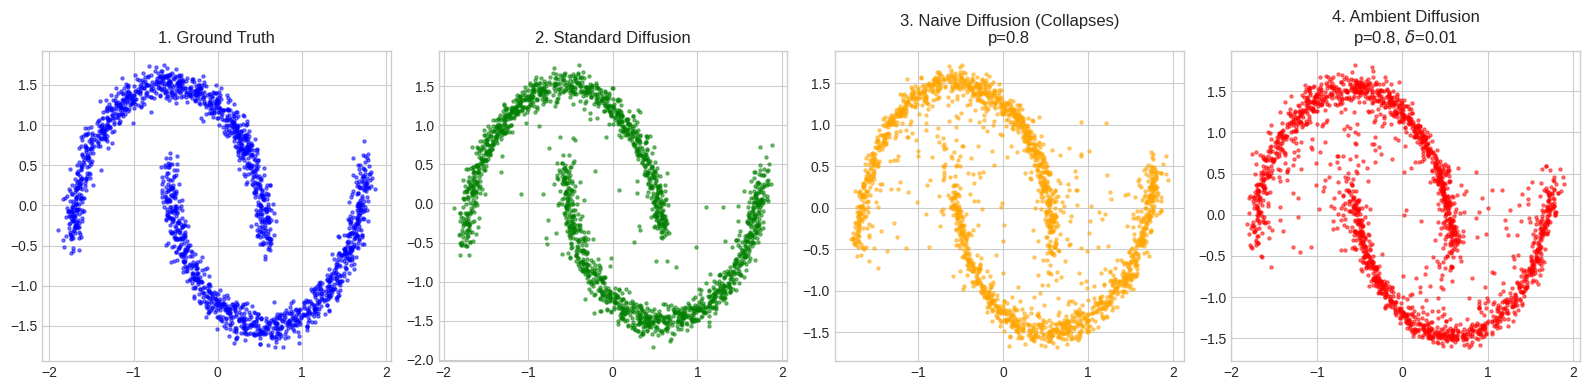

Generating vector fields...


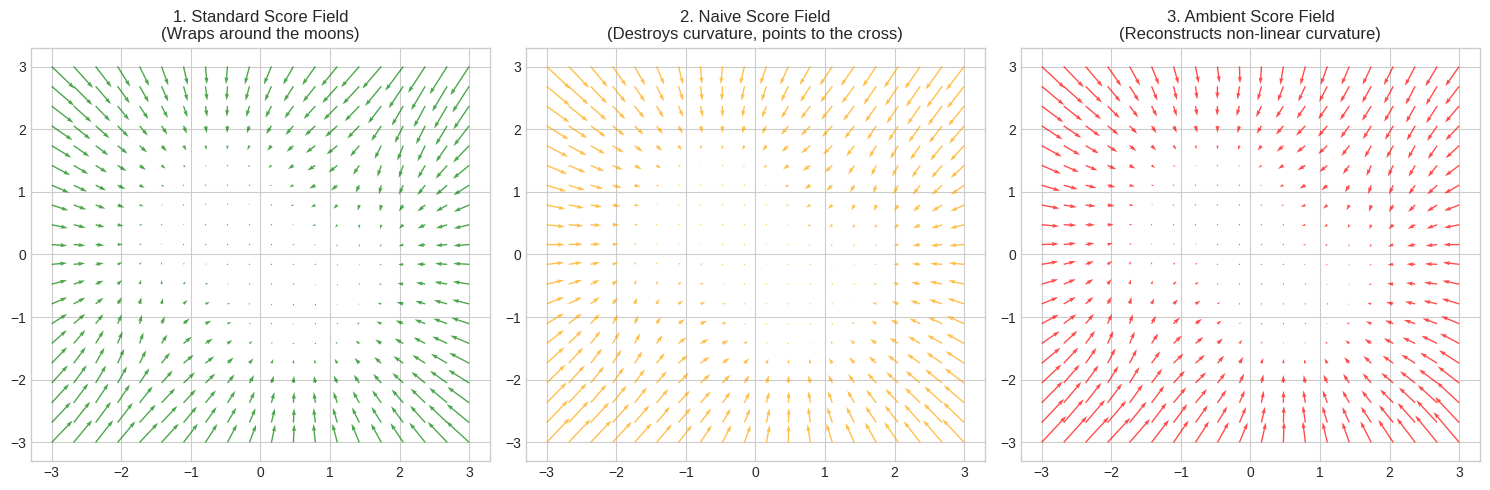

In [10]:
# ==============================================================================
# EXPERIMENT 2: TOPOLOGY (Two Moons)
# Objective: Prove that the method works on continuous non-linear manifolds
# ==============================================================================
print(">>> STARTING EXPERIMENT 2: TWO MOONS")
data_exp2 = generate_two_moons(n_samples=10000, noise=0.05)
p_val_2, delta_val_2, epochs_exp2 = 0.8, 0.01, 50000
operator_exp2 = ToyMaskingOperator(p=p_val_2, delta=delta_val_2)

# --- 0. VISUALIZING CORRUPTED DATA ---
print("0. Visualizing data before training...")
mask_A_2, _ = operator_exp2.corrupt_and_hat_corrupt(data_exp2)
data_corrupted_2 = data_exp2 * mask_A_2

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].scatter(data_exp2[:2000, 0].numpy(), data_exp2[:2000, 1].numpy(), s=5, alpha=0.5, c='blue')
axs[0].set_title("Ground Truth (Two Moons)")
axs[1].scatter(data_corrupted_2[:2000, 0].numpy(), data_corrupted_2[:2000, 1].numpy(), s=5, alpha=0.5, c='orange')
axs[1].set_title(f"Corrupted Data (p={p_val_2})\nDestruction of topology")

plt.tight_layout()
plt.savefig("exp2_corrupted_data.pdf")
plt.show()

# --- 1. TRAINING ---
print("1. Standard (Clean Data)...")
mod_std_2, _ = train_standard_diffusion(PreconditionedScoreNet(hidden_dim=256), data_exp2, epochs=epochs_exp2)
print("2. Naive (Will collapse)...")
mod_nai_2, _ = train_naive_diffusion(PreconditionedScoreNet(hidden_dim=256), data_exp2, operator_exp2, epochs=epochs_exp2)
print("3. Ambient (Corrupted Data)...")
mod_amb_2, _ = train_score_net(PreconditionedScoreNet(hidden_dim=256), data_exp2, operator_exp2, epochs=epochs_exp2)

# --- 2. GENERATION ---
sigmas = get_scheduler(num_steps=100)
gen_std_2 = sample_score_net(mod_std_2, 2000, sigmas)
gen_nai_2 = sample_score_net(mod_nai_2, 2000, sigmas)
gen_amb_2 = sample_score_net(mod_amb_2, 2000, sigmas)

# --- 3. METRICS CALCULATION AND DISPLAY ---
print("\n" + "="*65)
print("QUANTITATIVE METRICS: TOPOLOGY (TWO MOONS)")
print("="*65)

real_data_sample_2 = data_exp2[:2000]
metrics_std_2 = compute_metrics(real_data_sample_2, torch.tensor(gen_std_2, dtype=torch.float32))
metrics_nai_2 = compute_metrics(real_data_sample_2, torch.tensor(gen_nai_2, dtype=torch.float32))
metrics_amb_2 = compute_metrics(real_data_sample_2, torch.tensor(gen_amb_2, dtype=torch.float32))

print(f"{'Model':<20} | {'KDE LL (↑)':<12} | {'MMD (↓)':<10} | {'SWD (↓)':<10}")
print("-" * 65)
print(f"{'1. Standard':<20} | {metrics_std_2['KDE_LogLikelihood']:12.2f} | {metrics_std_2['MMD']:10.4f} | {metrics_std_2['SWD']:10.4f}")
print(f"{'2. Naive (Collapsed)':<20} | {metrics_nai_2['KDE_LogLikelihood']:12.2f} | {metrics_nai_2['MMD']:10.4f} | {metrics_nai_2['SWD']:10.4f}")
print(f"{'3. Ambient':<20} | {metrics_amb_2['KDE_LogLikelihood']:12.2f} | {metrics_amb_2['MMD']:10.4f} | {metrics_amb_2['SWD']:10.4f}")
print("="*65 + "\n")

# --- 4. FIGURE 1: SCATTER PLOTS ---
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].scatter(data_exp2[:2000, 0].numpy(), data_exp2[:2000, 1].numpy(), s=5, alpha=0.5, c='blue')
axs[0].set_title("1. Ground Truth")
axs[1].scatter(gen_std_2[:, 0], gen_std_2[:, 1], s=5, alpha=0.5, c='green')
axs[1].set_title("2. Standard Diffusion")
axs[2].scatter(gen_nai_2[:, 0], gen_nai_2[:, 1], s=5, alpha=0.5, c='orange')
axs[2].set_title(f"3. Naive Diffusion (Collapses)\np={p_val_2}")
axs[3].scatter(gen_amb_2[:, 0], gen_amb_2[:, 1], s=5, alpha=0.5, c='red')
axs[3].set_title(f"4. Ambient Diffusion\np={p_val_2}, $\\delta$={delta_val_2}")

plt.tight_layout()
plt.savefig("exp2_moons_scatter.pdf")
plt.show()

# --- 5. FIGURE 2: SCORE FIELDS ---
print("Generating vector fields...")
sigma_val_2 = 0.5

# The Two Moons space fits well between -3 and 3
x_range_2 = np.linspace(-3, 3, 20)
y_range_2 = np.linspace(-3, 3, 20)
X2, Y2 = np.meshgrid(x_range_2, y_range_2)

grid_points_2 = np.stack([X2.flatten(), Y2.flatten()], axis=1)
grid_tensor_2 = torch.tensor(grid_points_2, dtype=torch.float32, device=device)
dummy_mask_2 = torch.ones_like(grid_tensor_2, device=device)
sigma_tensor_2 = torch.full((len(grid_tensor_2), 1), sigma_val_2, device=device)

def get_uv_2(model):
    model.eval()
    with torch.no_grad():
        pred_x0 = model(grid_tensor_2, sigma_tensor_2, dummy_mask_2)
        score_dir = (pred_x0 - grid_tensor_2).cpu().numpy()
    return score_dir[:, 0].reshape(20, 20), score_dir[:, 1].reshape(20, 20)

U_std_2, V_std_2 = get_uv_2(mod_std_2)
U_nai_2, V_nai_2 = get_uv_2(mod_nai_2)
U_amb_2, V_amb_2 = get_uv_2(mod_amb_2)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

axs[0].quiver(X2, Y2, U_std_2, V_std_2, color='green', alpha=0.7)
axs[0].set_title("1. Standard Score Field\n(Wraps around the moons)")

axs[1].quiver(X2, Y2, U_nai_2, V_nai_2, color='orange', alpha=0.7)
axs[1].set_title("2. Naive Score Field\n(Destroys curvature, points to the cross)")

axs[2].quiver(X2, Y2, U_amb_2, V_amb_2, color='red', alpha=0.7)
axs[2].set_title("3. Ambient Score Field\n(Reconstructs non-linear curvature)")

plt.tight_layout()
plt.savefig("exp2_moons_quiver.pdf")
plt.show()

>>> STARTING EXPERIMENT 3: CORRUPTION SWEEP

Ambient Training for p = 0.3...


train_score_net: 100%|██████████| 5000/5000 [00:11<00:00, 424.33it/s]


Finished for p=0.3 -> KDE: -14.35 | MMD: 0.0219 | SWD: 0.6993

Ambient Training for p = 0.5...


train_score_net: 100%|██████████| 5000/5000 [00:11<00:00, 417.11it/s]


Finished for p=0.5 -> KDE: -4.97 | MMD: 0.0142 | SWD: 2.1054

Ambient Training for p = 0.7...


train_score_net: 100%|██████████| 5000/5000 [00:13<00:00, 370.80it/s]


Finished for p=0.7 -> KDE: -9.00 | MMD: 0.0324 | SWD: 3.0166

Ambient Training for p = 0.9...


train_score_net: 100%|██████████| 5000/5000 [00:11<00:00, 424.61it/s]


Finished for p=0.9 -> KDE: -27.43 | MMD: 0.0470 | SWD: 2.3282


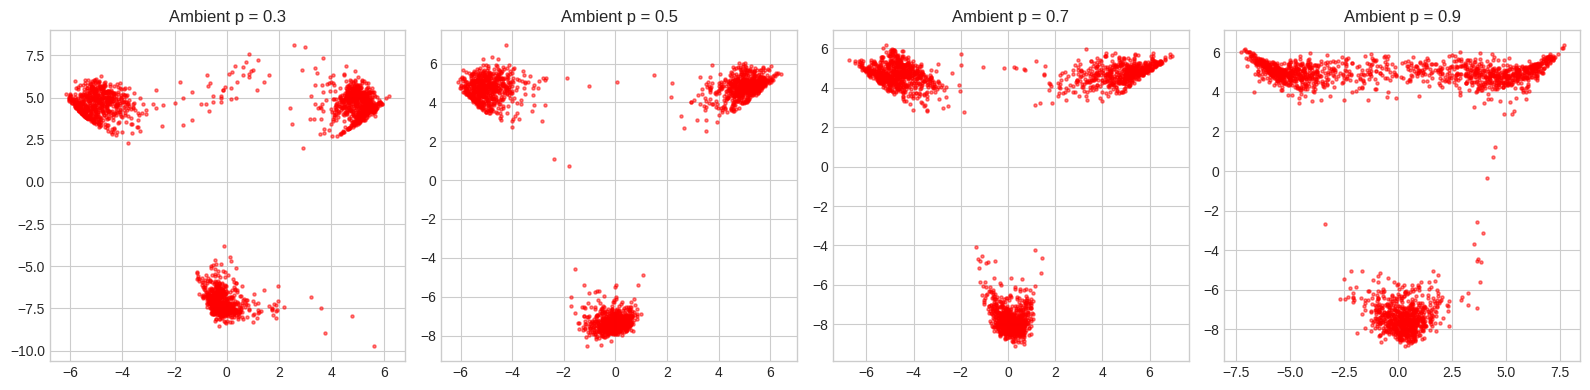


COPY THIS INTO YOUR LATEX TABLE (TABLE 1):
Method             | p   | KDE LL | MMD    | SWD
--------------------------------------------------
Ambient Diffusion  | 0.3 | -14.35 | 0.0219 | 0.6993
Ambient Diffusion  | 0.5 |  -4.97 | 0.0142 | 2.1054
Ambient Diffusion  | 0.7 |  -9.00 | 0.0324 | 3.0166
Ambient Diffusion  | 0.9 | -27.43 | 0.0470 | 2.3282


In [15]:
# ==============================================================================
# EXPERIMENT 3: DEGRADATION AS A FUNCTION OF CORRUPTION (Table 1 of the report)
# Objective: Train at p={0.3, 0.5, 0.7, 0.9} to populate quantitative metrics
# ==============================================================================
print(">>> STARTING EXPERIMENT 3: CORRUPTION SWEEP")
sweep_p = [0.3, 0.5, 0.7, 0.9]
sweep_gens = []
metrics_table = {}
epochs_exp3 = 5000 # Slightly shorter to speed up execution

for p in sweep_p:
    print(f"\nAmbient Training for p = {p}...")
    op_sweep = ToyMaskingOperator(p=p, delta=0.01)
    mod_swp, _ = train_score_net(PreconditionedScoreNet(hidden_dim=32), data_exp1, op_sweep, epochs=epochs_exp3)

    gen_swp = sample_score_net(mod_swp, 2000, sigmas)
    sweep_gens.append(gen_swp)

    m = compute_metrics(data_exp1[:2000], torch.tensor(gen_swp, dtype=torch.float32))
    metrics_table[p] = m
    print(f"Finished for p={p} -> KDE: {m['KDE_LogLikelihood']:.2f} | MMD: {m['MMD']:.4f} | SWD: {m['SWD']:.4f}")

# --- FIGURE 3: VISUAL EVOLUTION ---
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
for i, p in enumerate(sweep_p):
    axs[i].scatter(sweep_gens[i][:, 0], sweep_gens[i][:, 1], s=5, alpha=0.5, c='red')
    axs[i].set_title(f"Ambient p = {p}")
plt.tight_layout()
plt.savefig("exp3_sweep.pdf")
plt.show()

# --- PRINTING TABLE FOR LATEX ---
print("\n" + "="*50)
print("COPY THIS INTO YOUR LATEX TABLE (TABLE 1):")
print("="*50)
print(f"Method             | p   | KDE LL | MMD    | SWD")
print("-" * 50)
for p in sweep_p:
    m = metrics_table[p]
    print(f"Ambient Diffusion  | {p} | {m['KDE_LogLikelihood']:6.2f} | {m['MMD']:.4f} | {m['SWD']:.4f}")
print("="*50)

<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:37: SyntaxWarning: invalid escape sequence '\d'
<>:40: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_11472/2212393824.py:37: SyntaxWarning: invalid escape sequence '\d'
  axs[0].set_title(f"1. Trop petit ($\delta$={delta_list[0]})\nSignal trop faible")
/tmp/ipykernel_11472/2212393824.py:40: SyntaxWarning: invalid escape sequence '\d'
  axs[1].set_title(f"2. Sweet Spot ($\delta$={delta_list[1]})\nBonne reconstruction")
/tmp/ipykernel_11472/2212393824.py:43: SyntaxWarning: invalid escape sequence '\d'
  axs[2].set_title(f"3. Trop grand ($\delta$={delta_list[2]})\nBiais trop élevé")
/tmp/ipykernel_11472/2212393824.py:46: SyntaxWarning: invalid escape sequence '\d'
  axs[3]

>>> DÉBUT EXPÉRIENCE 4 : ABLATION DE DELTA

--- Entraînement Ambient pour delta = 0.001 (p=0.8) ---


train_score_net: 100%|██████████| 20000/20000 [00:47<00:00, 417.64it/s]


Résultat delta=0.001 -> KDE: -1.70 | MMD: 0.0009

--- Entraînement Ambient pour delta = 0.01 (p=0.8) ---


train_score_net: 100%|██████████| 20000/20000 [00:47<00:00, 418.89it/s]


Résultat delta=0.01 -> KDE: -1.54 | MMD: 0.0009

--- Entraînement Ambient pour delta = 0.1 (p=0.8) ---


train_score_net: 100%|██████████| 20000/20000 [00:47<00:00, 417.56it/s]


Résultat delta=0.1 -> KDE: -1.79 | MMD: 0.0013

--- Entraînement Ambient pour delta = 0.5 (p=0.8) ---


train_score_net: 100%|██████████| 20000/20000 [00:47<00:00, 421.70it/s]


Résultat delta=0.5 -> KDE: -2.84 | MMD: 0.0092


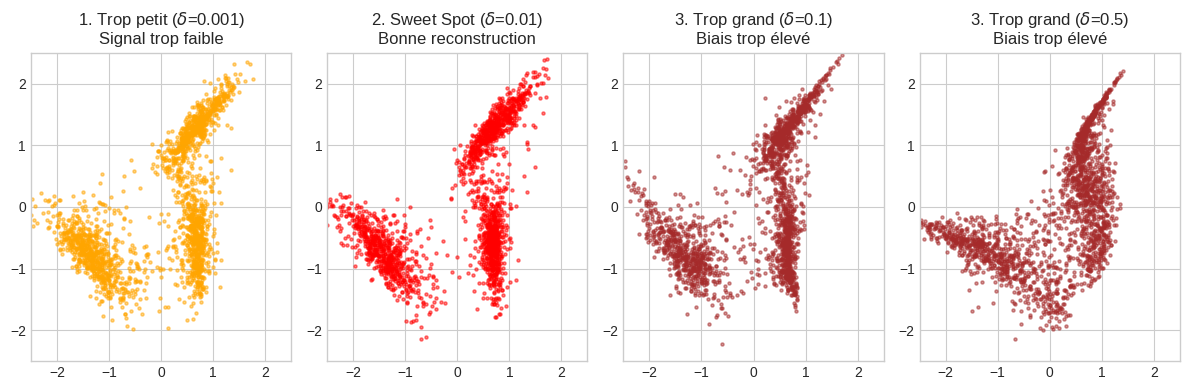

In [19]:
# ==============================================================================
# EXPÉRIENCE 4 : ABLATION DE DELTA (Le gouffre Théorie vs Pratique)
# Objectif : Fixer p=0.6 et faire varier delta = [0.01, 0.1, 0.5]
# ==============================================================================
print(">>> DÉBUT EXPÉRIENCE 4 : ABLATION DE DELTA")

# On utilise Two Moons, c'est très visuel pour voir si la forme est préservée
data_exp4 = generate_gmm()
p_fixed = 0.8
delta_list = [0.001, 0.01, 0.1, 0.5]
epochs_exp4 = 20000

delta_gens = []
delta_metrics = {}

for d in delta_list:
    print(f"\n--- Entraînement Ambient pour delta = {d} (p={p_fixed}) ---")
    op_delta = ToyMaskingOperator(p=p_fixed, delta=d)

    # On entraîne
    mod_d, _ = train_score_net(PreconditionedScoreNet(hidden_dim=32), data_exp4, op_delta, epochs=epochs_exp4)

    # On génère
    sigmas = get_scheduler(num_steps=100)
    gen_d = sample_score_net(mod_d, 2000, sigmas)
    delta_gens.append(gen_d)

    # On évalue
    m = compute_metrics(data_exp4[:2000], torch.tensor(gen_d, dtype=torch.float32))
    delta_metrics[d] = m
    print(f"Résultat delta={d} -> KDE: {m['KDE_LogLikelihood']:.2f} | MMD: {m['MMD']:.4f}")

# --- FIGURE 5 : COMPARAISON VISUELLE DES DELTAS ---
fig, axs = plt.subplots(1, 4, figsize=(12, 4))

axs[0].scatter(delta_gens[0][:, 0], delta_gens[0][:, 1], s=5, alpha=0.5, c='orange')
axs[0].set_title(f"1. Trop petit ($\delta$={delta_list[0]})\nSignal trop faible")

axs[1].scatter(delta_gens[1][:, 0], delta_gens[1][:, 1], s=5, alpha=0.5, c='red')
axs[1].set_title(f"2. Sweet Spot ($\delta$={delta_list[1]})\nBonne reconstruction")

axs[2].scatter(delta_gens[2][:, 0], delta_gens[2][:, 1], s=5, alpha=0.5, c='brown')
axs[2].set_title(f"3. Trop grand ($\delta$={delta_list[2]})\nBiais trop élevé")

axs[3].scatter(delta_gens[3][:, 0], delta_gens[3][:, 1], s=5, alpha=0.5, c='brown')
axs[3].set_title(f"3. Trop grand ($\delta$={delta_list[3]})\nBiais trop élevé")

for ax in axs: ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
plt.tight_layout()
plt.savefig("exp4_delta_ablation.pdf")
plt.show()